In [1]:
import wandb

import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from xaikd import models, datasets

from torch.utils.data import DataLoader
from xaikd.utils import metrics

from contextlib import nullcontext

from datetime import datetime

In [3]:
api = wandb.Api()

In [4]:
EXPERIMENT_GROUP = "./artifacts/2023-10-s16/experiments/ex3.1-basis-attention-varying-ts-clv"

In [32]:
def read_data(
    teacher,
    student,
    policy,
    lambda_task,
    lambda_kd,
    training_size,
    dataset,
    arr_contamination_levels,
    verbose=False,
    use_val_split=False,
):
    
    
    runs = api.runs(
        f'p16i/xaikd-distillation-layerwise-ep2',
        {
        "$and": [
            {"group": EXPERIMENT_GROUP},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.policy": policy},
            {"config.training_size": training_size},
            {"config.contamination_level": {"$in": arr_contamination_levels}},
            {"config.use_val_split": use_val_split},
            {"config.dataset": dataset}
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    count = 0
    
    datasets = []
    for run in runs:
        seed = run.config["seed"]
        
        if not "arr_metrics"in run.summary:
            print(">> bad run config")
            print(run.config)
            count += 1
            return run
            continue
                     
        k = np.argmax(run.summary["arr_metrics"]["val_acc"])
        datasets.append(run.config["dataset"])
        best_val_acc = run.summary["arr_metrics"]["val_acc"][k]
        best_val_agreement = run.summary["arr_metrics"]["val_agreement"][k]
        best_val_agreement_on_teacher_correct = run.summary["arr_metrics"]["val_agreement_on_teacher_correct"][k]


        rows.append(
            dict(
                best_epoch=k,
                seed=seed, 
                lambda_task=run.config["lambda_task"],
                lambda_kd=run.config["lambda_kd"],
                # remark: this is the actual value used in distillation
                # cf. https://github.com/p16i/xai-kd/blob/2023-09-s14--1-teacher-training-script/scripts/distill-layerwise.py#L364
                lambda_layer=run.config["policy_lambda_layer"],
                val_acc=best_val_acc, 
                val_agreement=best_val_agreement,
                val_agreement_on_teacher_correct=best_val_agreement_on_teacher_correct,
                teacher_acc=run.summary["teacher_acc"],
                policy=run.config["policy"],
                contamination_level=run.config["contamination_level"]
            )
        )
        
#     if verbose:
#         print("Missing dataset", set(CIFAR100_SUPERCLASSES).difference(datasets))

    if count != 0:
        print(f"We have {count} bad run! abort!")
        raise
    
    df = pd.DataFrame(rows)
        
        
    df = df.groupby(by="contamination_level").agg(
        {
            "val_acc": ["mean", "std", "count"],
            "val_agreement": ["mean", "std", "count"],
            "val_agreement_on_teacher_correct": ["mean", "std", "count"],
            "teacher_acc": ["mean"]
        }
    ).reset_index()
    if verbose:
        print(f"df.shape: {df.shape}")
    return df

summary = read_data(
    dataset="cifar100-people",
    teacher="cifar100-resnet18-v1",
    student="resnet18xscifarcompr1id",
    lambda_task=0.0,
    lambda_kd=1.0,
    policy="attention-transfer",
    training_size=1.0,
    verbose=True,
    arr_contamination_levels=[0.0, 0.25, 0.5, 0.75],
    use_val_split=False
)

summary

we have 12 runs
df.shape: (4, 11)


contamination_level   val_acc                 val_agreement                  \
                           mean       std count          mean       std count   
0                0.00  0.562000  0.012166     3      0.572000  0.003464     3   
1                0.25  0.525333  0.010263     3      0.552667  0.022301     3   
2                0.50  0.454000  0.023065     3      0.488000  0.019698     3   
3                0.75  0.370000  0.023065     3      0.420000  0.047286     3   

  val_agreement_on_teacher_correct                 teacher_acc  
                              mean       std count        mean  
0                         0.432000  0.008000     3    0.620000  
1                         0.410667  0.013317     3    0.614667  
2                         0.352000  0.015875     3    0.607333  
3                         0.292667  0.023180     3    0.604667

In [35]:
read_data(
    dataset="cifar100-people",
    teacher="cifar100-resnet18-v1",
    student="resnet18xscifarcompr1id",
    lambda_task=0.0,
    lambda_kd=1.0,
    policy="basis-attention:random--uncentered",
    training_size=1.0,
    verbose=True,
    arr_contamination_levels=[0.0, 0.25, 0.5, 0.75],
    use_val_split=False
)

we have 12 runs
df.shape: (4, 11)


contamination_level   val_acc                 val_agreement                  \
                           mean       std count          mean       std count   
0                0.00  0.552000  0.008718     3      0.549333  0.006110     3   
1                0.25  0.528000  0.042568     3      0.541333  0.029484     3   
2                0.50  0.461333  0.002309     3      0.486667  0.029484     3   
3                0.75  0.371333  0.011372     3      0.419333  0.031390     3   

  val_agreement_on_teacher_correct                 teacher_acc  
                              mean       std count        mean  
0                         0.422667  0.005773     3    0.620000  
1                         0.407333  0.024685     3    0.614667  
2                         0.359333  0.005773     3    0.607333  
3                         0.286000  0.020785     3    0.604667

# Comparison on `cifar100-resnet18-v1`

experiment group: ./artifacts/2023-10-s16/experiments/ex3.1-basis-attention-varying-ts-clv
date: 2023-10-11 21:17:11.737368


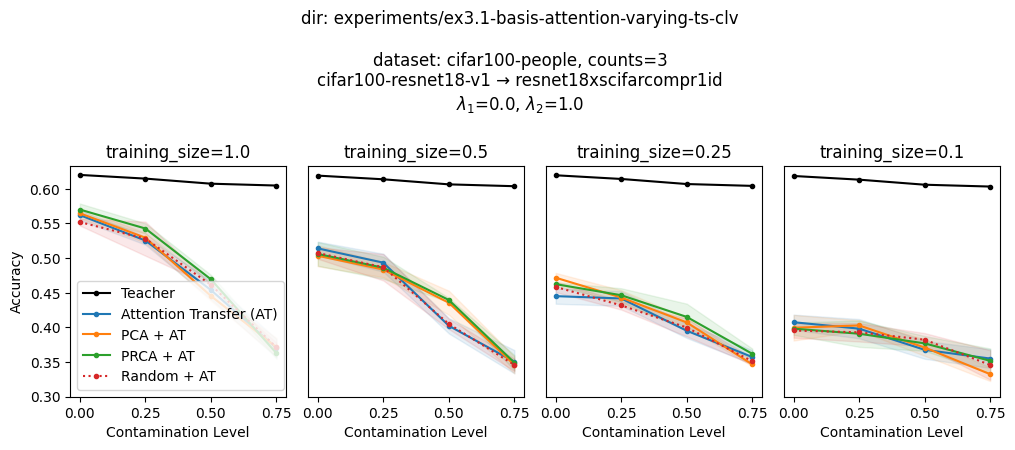

In [47]:
def ls(policy):
    if "random" in policy:
        return ":"
    else:
        return "-"
    
def marker(policy):
    return "."
    
    if "inner" in policy:
        return "."
    else:
        return None

def alias(student):
    alias_dict = {
        "basis-attention:pca--uncentered": "PCA + AT",
        "basis-attention:prca-sortabs--uncentered": "PRCA + AT",
        "basis-attention:random--uncentered": "Random + AT",
        "attention-transfer": "Attention Transfer (AT)",
    }

    return alias_dict.get(student, student)
    
    
def viz_distillation(
    teacher, policies,
    show_legend=True,
):
    arr_contamination_levels = [0.0, 0.25, 0.5, 0.75]
    arr_training_sizes = [1.0, 0.5, 0.25, 0.1]
    lambda_kd = 1.0
    lambda_task = 0.0
            
    dataset = "cifar100-people"
    col = "val_acc"
    
    student = 'resnet18xscifarcompr1id'
    
    ncols = len(arr_training_sizes)
    nrows = 1
    
    plt.figure(figsize=(3*ncols, 3*nrows))
    
    dirslug = "/".join(f"{EXPERIMENT_GROUP}".split("/")[-2:])

    count = None
    
    print("============")
    print(f"experiment group: {EXPERIMENT_GROUP}")
    print(f"date: {datetime.now()}")
    for tix, training_size in enumerate(arr_training_sizes):
        plt.subplot(nrows, ncols, tix+1)
        plt.title(f"training_size={training_size}")
        for pix, policy in enumerate(policies):

            df = read_data(
                teacher=teacher,
                student=student,
                dataset=dataset,
                policy=policy,
                lambda_task=lambda_task,
                lambda_kd=lambda_kd,
                training_size=training_size,
                arr_contamination_levels=arr_contamination_levels,
                verbose=False
            )


            with nullcontext(enter_result="sanity check"):            
                if count == None:

                    np.testing.assert_equal(
                        df[col]["count"].values,
                        df[col]["count"].values[0]
                    )

                    count = df[col]["count"].values[0]
                else:
                    np.testing.assert_equal(df[col]["count"].values, count)  
                    pass 

                if not (df[col]["count"].values == df[col]["count"].values[0]).all() \
                    or df[col]["count"].values[0] != count:
                        print(f"[warning] policy={policy}:", df[col]["count"].values)    

            ticks = df["contamination_level"]
              
            if pix == 0:
                plt.plot(
                    ticks,
                    df["teacher_acc"].values,
                    marker=".",
                    color="k",
                    label="Teacher"
                )

            mean = df[col]["mean"]
            stderr = df[col]["std"] / (count ** 0.5)


            plt.plot(
                ticks,
                mean,
                marker=".",
                label=alias(policy),
                ls=ls(policy)
            )

            plt.fill_between(
                ticks,
                mean - stderr,
                mean + stderr,
                alpha=0.1,
                color=plt.gca().lines[-1].get_color()
            )


        plt.xlabel("Contamination Level")
        plt.ylabel(col)
        plt.xticks(ticks)
        plt.ylim(bottom=0.3)

        if tix == 0:
            plt.legend()
            plt.ylabel("Accuracy")
        else:
            plt.ylabel("")
            plt.yticks([])

    
    plt.suptitle(
        "\n".join([
            f"dir: {dirslug}",
            "",
            f"dataset: {dataset}, counts={count}",
            f"{teacher} → {student}",
            f"$\lambda_1$={lambda_task}, $\lambda_2$={lambda_kd}",
            "",
        ]),
        y=1.4,
    )
    
    plt.subplots_adjust(hspace=0.5, wspace=0.1)


viz_distillation(
    teacher = "cifar100-resnet18-v1",
    
    policies = [ 
        "attention-transfer",
        f"basis-attention:pca--uncentered",
        f"basis-attention:prca-sortabs--uncentered",
        f"basis-attention:random--uncentered",
    ],
)

# Summary

Setup:
<!-- $$
 (0.0) \ell_\text{task} + \lambda_2 \ell_\text{KD} + \lambda_3 \ell_\text{layer},
$$
$\lambda_2 = 1$ and $\lambda_3 = \{0, 10^{-3}, 10^{-2}, \dots,  10^6\}$
 -->
*Aims:* 
<!-- - investigate the usage of basis in attention transfer. -->

*Conclusion:* 
<!-- - we can see that projecting teacher feature first onto the `pca` or `prca` basis before performing attention transfer show some benefitial.

*Next step*
- varying traning size and contamination levels. -->